<a href="https://colab.research.google.com/github/HK25abm/Transformer-Phishing-Detection/blob/main/Final_Model_Comparison_BERT_RoBERTa_DeBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers datasets accelerate evaluate sentencepiece scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


In [2]:
import gc
import os
import random
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

CUDA available: True
GPU: Tesla T4


In [4]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

train_df.head()

Training: (14000, 10)
Validation: (3000, 10)
Testing: (3000, 10)


,text,label,source,urls,sender,receiver,date,subject,body,sample_id
0,Message-ID: <23977441.1075845143515.JavaMail.e...,0,Enron,0,NaN,NaN,NaN,NaN,NaN,EMAIL_000472
1,Service Suspension Notification. Dear Customer...,1,Modern,1,"""Fidelity Investments."" <bcornett@pacific.net>",Recipients <bcornett@pacific.net>,2021-01-27 16:57:27,Service Suspension Notification.,"Dear Customer, This is a notification that you...",EMAIL_013246
2,Your ex-gf will be begging to come back to her...,1,CEAS,0,NaN,NaN,NaN,NaN,NaN,EMAIL_012729
3,Message-ID: <25438508.1075840399417.JavaMail.e...,0,Enron,0,NaN,NaN,NaN,NaN,NaN,EMAIL_008321
4,All Your Breast Enlargement Info From Top Brea...,1,CEAS,1,NaN,NaN,NaN,NaN,NaN,EMAIL_016205


In [5]:
required_columns = {"text", "label"}

for name, frame in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():
    missing = required_columns - set(frame.columns)

    if missing:
        raise ValueError(
            f"{name} is missing columns: {missing}"
        )

In [6]:
def prepare_split(frame):
    frame = frame.copy()

    frame = frame.dropna(
        subset=["text", "label"]
    )

    frame["text"] = frame["text"].astype(str)
    frame["label"] = frame["label"].astype(int)

    frame = frame[
        frame["label"].isin([0, 1])
    ]

    frame = frame.reset_index(drop=True)

    return frame


train_df = prepare_split(train_df)
val_df = prepare_split(val_df)
test_df = prepare_split(test_df)

In [7]:
for name, frame in {
    "Training": train_df,
    "Validation": val_df,
    "Testing": test_df
}.items():
    print(f"\n{name}:")
    print(frame["label"].value_counts())


Training:
label
0    7000
1    7000
Name: count, dtype: int64

Validation:
label
0    1500
1    1500
Name: count, dtype: int64

Testing:
label
1    1500
0    1500
Name: count, dtype: int64


In [8]:
train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print(
    "Train–validation overlap:",
    len(train_texts & val_texts)
)

print(
    "Train–test overlap:",
    len(train_texts & test_texts)
)

print(
    "Validation–test overlap:",
    len(val_texts & test_texts)
)

Train–validation overlap: 0
Train–test overlap: 0
Validation–test overlap: 0


In [9]:
val_df = val_df[
    ~val_df["text"].isin(train_texts)
].reset_index(drop=True)

test_df = test_df[
    ~test_df["text"].isin(
        train_texts | set(val_df["text"])
    )
].reset_index(drop=True)

In [10]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

In [11]:
class EmailDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length=256
    ):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        encoding = self.tokenizer(
            self.texts[index],
            truncation=True,
            max_length=self.max_length
        )

        encoding["labels"] = self.labels[index]

        return encoding

In [12]:
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=1
    ).numpy()

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            labels,
            probabilities[:, 1]
        )
    }

In [13]:
MODEL_CONFIGS = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "DeBERTa": "microsoft/deberta-v3-base"
}

In [14]:
def train_and_evaluate_model(
    model_display_name,
    model_checkpoint,
    max_length=256
):
    print("=" * 70)
    print(f"Starting {model_display_name}")
    print(f"Checkpoint: {model_checkpoint}")
    print("=" * 70)

    tokenizer = AutoTokenizer.from_pretrained(
        model_checkpoint,
        use_fast=True
    )

    train_dataset = EmailDataset(
        train_df["text"],
        train_df["label"],
        tokenizer,
        max_length=max_length
    )

    validation_dataset = EmailDataset(
        val_df["text"],
        val_df["label"],
        tokenizer,
        max_length=max_length
    )

    test_dataset = EmailDataset(
        test_df["text"],
        test_df["label"],
        tokenizer,
        max_length=max_length
    )

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=2,
        id2label={
            0: "Legitimate",
            1: "Phishing"
        },
        label2id={
            "Legitimate": 0,
            "Phishing": 1
        }
    )

    output_directory = (
        f"./final_models/"
        f"{model_display_name.lower()}"
    )

    training_args = TrainingArguments(
        output_dir=output_directory,

        learning_rate=2e-5,

        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,

        per_device_eval_batch_size=16,

        num_train_epochs=3,
        weight_decay=0.01,

        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        save_total_limit=1,

        fp16=torch.cuda.is_available(),

        report_to="none",
        seed=SEED,
        data_seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ]
    )

    start_time = time.time()

    training_output = trainer.train()

    training_time = time.time() - start_time

    test_output = trainer.predict(
        test_dataset
    )

    test_logits = test_output.predictions
    y_true = test_output.label_ids

    test_probabilities = torch.softmax(
        torch.tensor(test_logits),
        dim=1
    ).numpy()

    y_pred = np.argmax(
        test_probabilities,
        axis=1
    )

    metrics = {
        "Model": model_display_name,
        "Checkpoint": model_checkpoint,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            test_probabilities[:, 1]
        ),
        "Training Time Seconds": training_time,
        "Best Checkpoint":
            trainer.state.best_model_checkpoint
    }

    os.makedirs(
        "./final_outputs",
        exist_ok=True
    )

    safe_name = model_display_name.lower()

    report = classification_report(
        y_true,
        y_pred,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4,
        output_dict=True
    )

    pd.DataFrame(report).transpose().to_csv(
        f"./final_outputs/"
        f"{safe_name}_classification_report.csv"
    )

    prediction_frame = test_df.copy()

    prediction_frame["predicted_label"] = y_pred
    prediction_frame["legitimate_probability"] = (
        test_probabilities[:, 0]
    )
    prediction_frame["phishing_probability"] = (
        test_probabilities[:, 1]
    )

    prediction_frame.to_csv(
        f"./final_outputs/"
        f"{safe_name}_test_predictions.csv",
        index=False
    )

    confusion = confusion_matrix(
        y_true,
        y_pred
    )

    ConfusionMatrixDisplay(
        confusion_matrix=confusion,
        display_labels=[
            "Legitimate",
            "Phishing"
        ]
    ).plot(values_format="d")

    plt.title(
        f"{model_display_name} Confusion Matrix"
    )
    plt.tight_layout()
    plt.savefig(
        f"./final_outputs/"
        f"{safe_name}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    RocCurveDisplay.from_predictions(
        y_true,
        test_probabilities[:, 1],
        name=model_display_name
    )

    plt.title(
        f"{model_display_name} ROC Curve"
    )
    plt.tight_layout()
    plt.savefig(
        f"./final_outputs/"
        f"{safe_name}_roc_curve.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    log_history = pd.DataFrame(
        trainer.state.log_history
    )

    log_history.to_csv(
        f"./final_outputs/"
        f"{safe_name}_training_log.csv",
        index=False
    )

    trainer.save_model(
        f"./final_models/{safe_name}/best_model"
    )

    tokenizer.save_pretrained(
        f"./final_models/{safe_name}/best_model"
    )

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Legitimate",
                "Phishing"
            ],
            digits=4
        )
    )

    print(metrics)

    del model
    del trainer
    del train_dataset
    del validation_dataset
    del test_dataset

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

Starting BERT
Checkpoint: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.000066,0.000017,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.000026,0.000008,1.000000,1.000000,1.000000,1.000000,1.000000
3,0.000019,0.000006,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

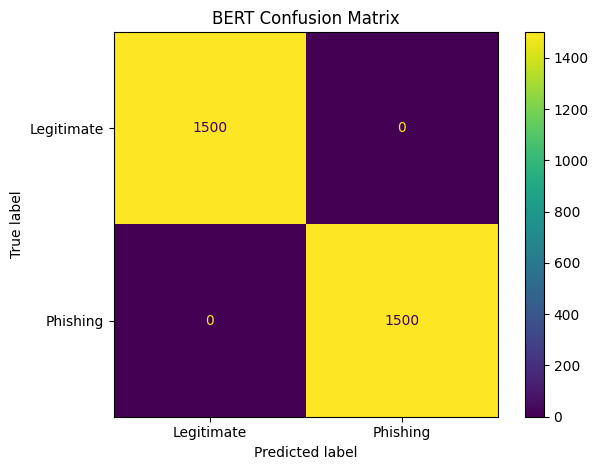

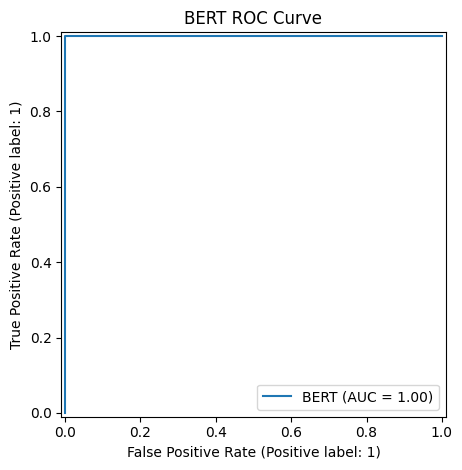

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

  Legitimate     1.0000    1.0000    1.0000      1500
    Phishing     1.0000    1.0000    1.0000      1500

    accuracy                         1.0000      3000
   macro avg     1.0000    1.0000    1.0000      3000
weighted avg     1.0000    1.0000    1.0000      3000

{'Model': 'BERT', 'Checkpoint': 'bert-base-uncased', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1-score': 1.0, 'ROC-AUC': np.float64(1.0), 'Training Time Seconds': 757.8272430896759, 'Best Checkpoint': './final_models/bert/checkpoint-875'}


In [15]:
bert_metrics = train_and_evaluate_model(
    model_display_name="BERT",
    model_checkpoint="bert-base-uncased",
    max_length=256
)

In [ ]:
roberta_metrics = train_and_evaluate_model(
    model_display_name="RoBERTa",
    model_checkpoint="roberta-base",
    max_length=256
)

In [ ]:
deberta_metrics = train_and_evaluate_model(
    model_display_name="DeBERTa",
    model_checkpoint="microsoft/deberta-v3-base",
    max_length=256
)

In [ ]:
per_device_train_batch_size=4
gradient_accumulation_steps=4
per_device_eval_batch_size=8

In [ ]:
comparison_df = pd.DataFrame([
    bert_metrics,
    roberta_metrics,
    deberta_metrics
])

comparison_df

In [ ]:
comparison_df = comparison_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Training Time Seconds",
        "Checkpoint",
        "Best Checkpoint"
    ]
]

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

comparison_df[metric_columns] = (
    comparison_df[metric_columns]
    .round(4)
)

comparison_df.to_csv(
    "./final_outputs/"
    "bert_roberta_deberta_comparison.csv",
    index=False
)

comparison_df

In [ ]:
comparison_plot = comparison_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title(
    "BERT, RoBERTa and DeBERTa Performance Comparison"
)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    "./final_outputs/"
    "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
best_model_row = comparison_df.sort_values(
    by=[
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    ascending=False
).iloc[0]

best_model_row

In [ ]:
import shutil

shutil.make_archive(
    "Final_Transformer_Experiments",
    "zip",
    ".",
    root_dir="."
)

In [ ]:
import os
import shutil

os.makedirs(
    "experiment_package",
    exist_ok=True
)

shutil.copytree(
    "final_outputs",
    "experiment_package/final_outputs",
    dirs_exist_ok=True
)

shutil.copytree(
    "final_models",
    "experiment_package/final_models",
    dirs_exist_ok=True
)

for dataset_file in [
    "train.csv",
    "validation.csv",
    "test.csv"
]:
    shutil.copy(
        dataset_file,
        f"experiment_package/{dataset_file}"
    )

shutil.make_archive(
    "Final_Transformer_Experiments",
    "zip",
    "experiment_package"
)

In [17]:
from google.colab import files

files.download(
    "Final_Transformer_Experiments.zip"
)

FileNotFoundError: Cannot find file: Final_Transformer_Experiments.zip